# Model Experiments on Original Normalized Data (n = 1481)

This notebook runs all classification models on the original dataset.

## Models:
1. Random Forest Classifier
2. Gradient Boosting Classifier
3. XGBoost Classifier
4. CatBoost Classifier
5. Logistic Regression
6. Artificial Neural Network (PyTorch)

## Target: CGPA3_Class (3 classes)
- Class 0 (normalized: 0.0) = CGPA 3.5-4.0
- Class 1 (normalized: 0.5) = CGPA 3.0-3.49
- Class 2 (normalized: 1.0) = CGPA <3.0

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier
from xgboost import XGBClassifier

# Deep Learning - PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Train-Test Split and Metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, balanced_accuracy_score, roc_auc_score
)

# Check device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print("All libraries imported successfully!")

Using device: cuda
All libraries imported successfully!


## 2. Load Balanced Normalized Data

In [2]:
# Load the GAN-augmented balanced normalized data
df = pd.read_csv(r'../data/Final_Encoded_Normalized.csv')

print(f"Dataset Shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
df.head()

Dataset Shape: (1481, 31)

Columns: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Current_CGPA5', 'CGPA3_Class', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


,Age,Gender,Where_live,AVG_Sleep_Per_Night,Regular_Bed_time,Exam_Night_Bed_Time,Holiday_Bed_Time,Regular_WakeUp_Time,Holiday_WakeUp_Time,Have_Regular_Bed_Time,...,Class_Attendance,Sleepiness_During_Class,Skip_Class_for_Sleep,Focus_on_Academic_Task,Impact_of_Sleep_on_Academic,Current_CGPA5,CGPA3_Class,Aware_of_Recomamended_Sleep,Use_Sleep_Tracking_Devices,Sacrifices_Sleep_for_Academics
0,0.666667,1.0,0.0,1.000000,1.00,1.00,1.00,1.0,1.0,0.0,...,0.333333,0.666667,0.0,0.0,0.75,0.50,0.5,1.0,0.0,1.0
1,0.666667,0.0,0.5,0.333333,0.75,0.25,0.25,0.5,1.0,0.0,...,0.333333,0.000000,1.0,0.5,0.75,0.75,0.5,1.0,0.0,1.0
2,0.666667,0.0,0.5,0.000000,1.00,1.00,1.00,0.5,1.0,0.0,...,0.000000,0.000000,1.0,0.0,0.00,0.75,0.5,1.0,0.0,1.0
3,1.000000,0.0,0.5,0.666667,0.50,0.75,1.00,0.5,1.0,0.0,...,0.000000,0.000000,0.0,1.0,0.25,0.75,0.5,1.0,0.0,1.0
4,0.666667,0.0,0.0,0.333333,0.75,0.75,0.75,0.5,0.5,0.0,...,1.000000,0.333333,0.0,0.5,0.25,0.75,0.5,0.0,0.0,1.0


In [3]:
# Check class distribution
TARGET_COLUMN = 'CGPA3_Class'

print("Class Distribution (Normalized Values):")
print(df[TARGET_COLUMN].value_counts().sort_index())

# Convert normalized target back to integer classes for modeling
# 0.0 -> 0, 0.5 -> 1, 1.0 -> 2
df['Target'] = (df[TARGET_COLUMN] * 2).round().astype(int)

print("\nConverted Target Classes:")
print(df['Target'].value_counts().sort_index())
print("\n0 = CGPA 3.5-4.0 (High)")
print("1 = CGPA 3.0-3.49 (Average)")
print("2 = CGPA <3.0 (Low)")

Class Distribution (Normalized Values):
CGPA3_Class
0.0    655
0.5    608
1.0    218
Name: count, dtype: int64

Converted Target Classes:
Target
0    655
1    608
2    218
Name: count, dtype: int64

0 = CGPA 3.5-4.0 (High)
1 = CGPA 3.0-3.49 (Average)
2 = CGPA <3.0 (Low)


## 3. Prepare Features and Target

In [4]:
# Define features (exclude target columns)
exclude_cols = ['CGPA3_Class', 'Target', 'Current_CGPA5']  # Exclude target and related columns
feature_cols = [col for col in df.columns if col not in exclude_cols]

print(f"Number of features: {len(feature_cols)}")
print(f"Features: {feature_cols}")

Number of features: 29
Features: ['Age', 'Gender', 'Where_live', 'AVG_Sleep_Per_Night', 'Regular_Bed_time', 'Exam_Night_Bed_Time', 'Holiday_Bed_Time', 'Regular_WakeUp_Time', 'Holiday_WakeUp_Time', 'Have_Regular_Bed_Time', 'Daytime_Nap', 'Struggle_to_Sleep', 'Sleep_Condition', 'Electronic_Devices_Before_Bed', 'Consume_Caffeine_Night', 'Dinnar_Time', 'Smoke', 'Sleep_Affecting_Drugs', 'Daily_Academics_Time_Spend', 'Main_Reason_for_Insufficient_Sleep', 'Rate_Sleep_Quality', 'Class_Attendance', 'Sleepiness_During_Class', 'Skip_Class_for_Sleep', 'Focus_on_Academic_Task', 'Impact_of_Sleep_on_Academic', 'Aware_of_Recomamended_Sleep', 'Use_Sleep_Tracking_Devices', 'Sacrifices_Sleep_for_Academics']


In [5]:
# Prepare X and y
X = df[feature_cols].values
y = df['Target'].values

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
unique, counts = np.unique(y_train, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_train)*100:.1f}%)")

print(f"\nTest class distribution:")
unique, counts = np.unique(y_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  Class {u}: {c} ({c/len(y_test)*100:.1f}%)")

Training set: 1184 samples
Test set: 297 samples

Training class distribution:
  Class 0: 524 (44.3%)
  Class 1: 486 (41.0%)
  Class 2: 174 (14.7%)

Test class distribution:
  Class 0: 131 (44.1%)
  Class 1: 122 (41.1%)
  Class 2: 44 (14.8%)


## 4. Helper Functions

In [6]:
# Store all results
all_results = []

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evaluate model and return metrics
    """
    y_pred = model.predict(X_test)
    
    # For models that support predict_proba
    try:
        y_prob = model.predict_proba(X_test)
        roc_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
    except:
        roc_auc = None
    
    accuracy = accuracy_score(y_test, y_pred)
    macro_f1 = f1_score(y_test, y_pred, average='macro')
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    
    result = {
        'Model': model_name,
        'Accuracy': round(accuracy, 4),
        'Macro F1-Score': round(macro_f1, 4),
        'Balanced Accuracy': round(balanced_acc, 4),
        'ROC-AUC': round(roc_auc, 4) if roc_auc else 'N/A'
    }
    
    all_results.append(result)
    return result, y_pred

def plot_confusion_matrix(y_test, y_pred, model_name):
    """
    Plot confusion matrix
    """
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'],
                yticklabels=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()

def print_classification_report(y_test, y_pred, model_name):
    """
    Print classification report
    """
    print(f"\n{'='*60}")
    print(f"Classification Report - {model_name}")
    print('='*60)
    print(classification_report(y_test, y_pred, 
          target_names=['High (3.5-4.0)', 'Avg (3.0-3.49)', 'Low (<3.0)']))

---
## 5. Model 1: Random Forest Classifier

In [7]:
print("Training Random Forest Classifier...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
result, y_pred_rf = evaluate_model(rf_model, X_test, y_test, 'Random Forest')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Random Forest Classifier...

Results:
  Model: Random Forest
  Accuracy: 0.4747
  Macro F1-Score: 0.4567
  Balanced Accuracy: 0.4434
  ROC-AUC: 0.6107


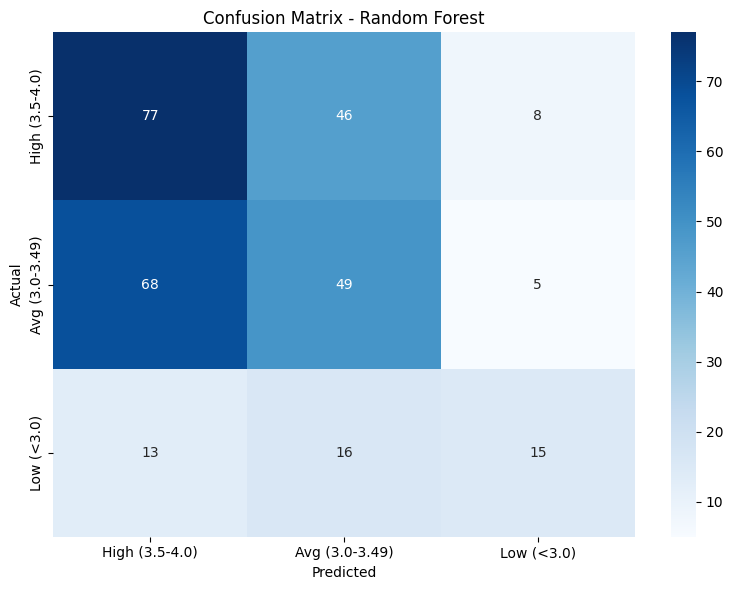


Classification Report - Random Forest
                precision    recall  f1-score   support

High (3.5-4.0)       0.49      0.59      0.53       131
Avg (3.0-3.49)       0.44      0.40      0.42       122
    Low (<3.0)       0.54      0.34      0.42        44

      accuracy                           0.47       297
     macro avg       0.49      0.44      0.46       297
  weighted avg       0.48      0.47      0.47       297



In [8]:
plot_confusion_matrix(y_test, y_pred_rf, 'Random Forest')
print_classification_report(y_test, y_pred_rf, 'Random Forest')

---
## 6. Model 2: Gradient Boosting Classifier

In [9]:
print("Training Gradient Boosting Classifier...")

gb_model = GradientBoostingClassifier(
    n_estimators=300,          # 100 → 300
    max_depth=6,               # 5 → 6
    learning_rate=0.05,        # 0.1 → 0.05
    min_samples_split=5,       # NEW (default is 2)
    min_samples_leaf=3,        # NEW (default is 1)
    subsample=0.8,             # NEW (stochastic GB)
    max_features='sqrt',       # NEW (feature sampling)
    validation_fraction=0.1,   # NEW (early stopping data)
    n_iter_no_change=20,       # NEW (early stopping patience)
    random_state=42
)

gb_model.fit(X_train, y_train)
result, y_pred_gb = evaluate_model(gb_model, X_test, y_test, 'Gradient Boosting')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Gradient Boosting Classifier...

Results:
  Model: Gradient Boosting
  Accuracy: 0.5051
  Macro F1-Score: 0.4552
  Balanced Accuracy: 0.4464
  ROC-AUC: 0.6342


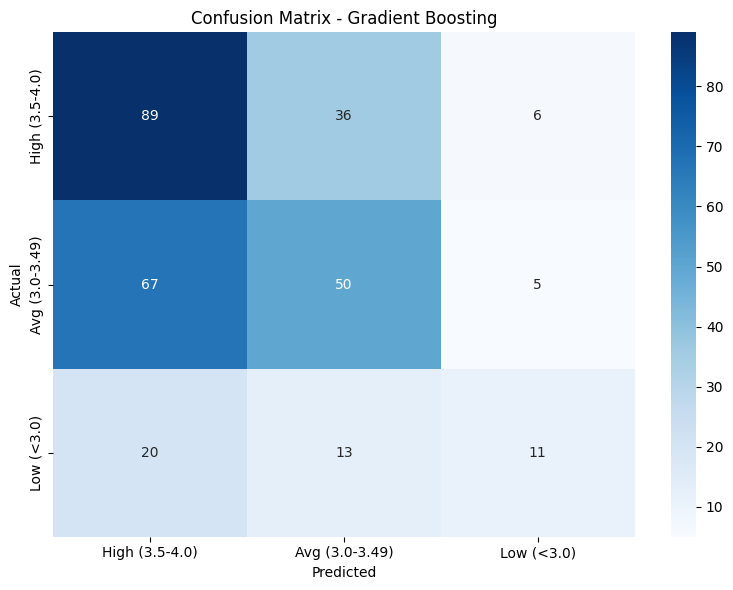


Classification Report - Gradient Boosting
                precision    recall  f1-score   support

High (3.5-4.0)       0.51      0.68      0.58       131
Avg (3.0-3.49)       0.51      0.41      0.45       122
    Low (<3.0)       0.50      0.25      0.33        44

      accuracy                           0.51       297
     macro avg       0.50      0.45      0.46       297
  weighted avg       0.50      0.51      0.49       297



In [10]:
plot_confusion_matrix(y_test, y_pred_gb, 'Gradient Boosting')
print_classification_report(y_test, y_pred_gb, 'Gradient Boosting')

---
## 7. Model 3: XGBoost Classifier

In [11]:
print("Training XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=300,        # 100 → 300
    max_depth=6,             # 5 → 6
    learning_rate=0.05,      # 0.1 → 0.05
    min_child_weight=3,      # NEW (prevent overfitting)
    subsample=0.8,           # NEW (row sampling)
    colsample_bytree=0.8,    # NEW (column sampling)
    gamma=1,                 # NEW (min loss reduction)
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

xgb_model.fit(X_train, y_train)
result, y_pred_xgb = evaluate_model(xgb_model, X_test, y_test, 'XGBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training XGBoost Classifier...

Results:
  Model: XGBoost
  Accuracy: 0.5219
  Macro F1-Score: 0.5066
  Balanced Accuracy: 0.4951
  ROC-AUC: 0.6375


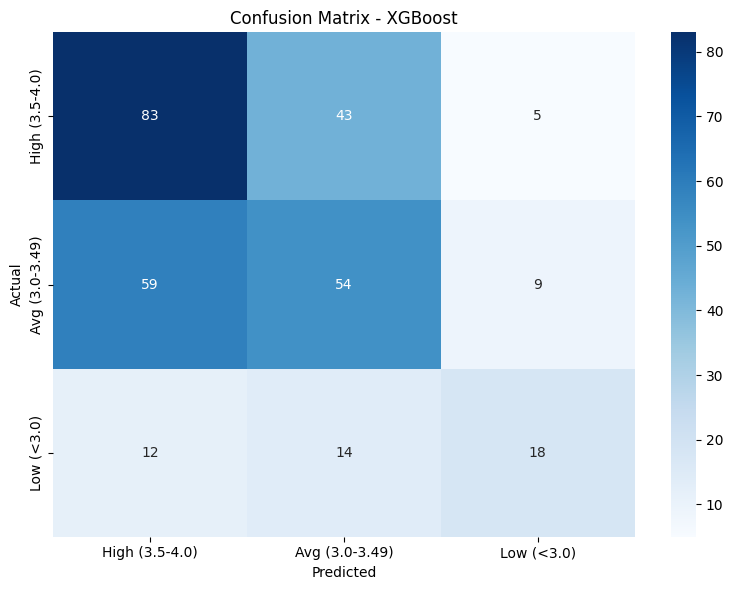


Classification Report - XGBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.54      0.63      0.58       131
Avg (3.0-3.49)       0.49      0.44      0.46       122
    Low (<3.0)       0.56      0.41      0.47        44

      accuracy                           0.52       297
     macro avg       0.53      0.50      0.51       297
  weighted avg       0.52      0.52      0.52       297



In [12]:
plot_confusion_matrix(y_test, y_pred_xgb, 'XGBoost')
print_classification_report(y_test, y_pred_xgb, 'XGBoost')

---
## 8. Model 4: CatBoost Classifier

In [13]:
print("Training CatBoost Classifier...")

catboost_model = CatBoostClassifier(
    iterations=100,
    depth=5,
    learning_rate=0.1,
    random_state=42,
    verbose=False
)

catboost_model.fit(X_train, y_train)
result, y_pred_cat = evaluate_model(catboost_model, X_test, y_test, 'CatBoost')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training CatBoost Classifier...

Results:
  Model: CatBoost
  Accuracy: 0.4949
  Macro F1-Score: 0.4766
  Balanced Accuracy: 0.4639
  ROC-AUC: 0.6203


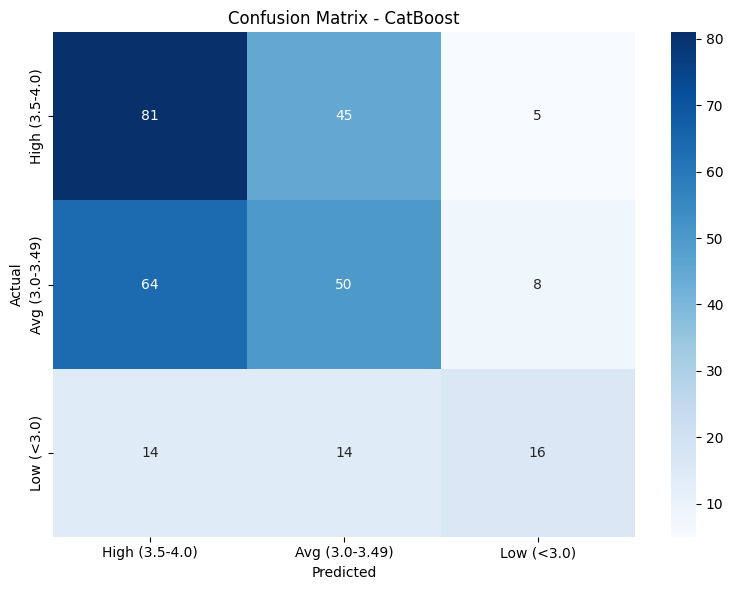


Classification Report - CatBoost
                precision    recall  f1-score   support

High (3.5-4.0)       0.51      0.62      0.56       131
Avg (3.0-3.49)       0.46      0.41      0.43       122
    Low (<3.0)       0.55      0.36      0.44        44

      accuracy                           0.49       297
     macro avg       0.51      0.46      0.48       297
  weighted avg       0.49      0.49      0.49       297



In [14]:
plot_confusion_matrix(y_test, y_pred_cat, 'CatBoost')
print_classification_report(y_test, y_pred_cat, 'CatBoost')

---
## 9. Model 5: Logistic Regression

In [15]:
print("Training Logistic Regression...")

lr_model = LogisticRegression(
    max_iter=2000,             # 1000 → 2000
    C=0.5,                     # NEW (less regularization, default is 1.0)
    penalty='elasticnet',      # NEW (L1 + L2 combined)
    solver='saga',             # lbfgs → saga (supports elasticnet)
    l1_ratio=0.5,              # NEW (balance between L1 and L2)
    multi_class='multinomial',
    class_weight='balanced',   # NEW (handle class imbalance)
    random_state=42,
    n_jobs=-1
)

lr_model.fit(X_train, y_train)
result, y_pred_lr = evaluate_model(lr_model, X_test, y_test, 'Logistic Regression')

print(f"\nResults:")
for key, value in result.items():
    print(f"  {key}: {value}")

Training Logistic Regression...

Results:
  Model: Logistic Regression
  Accuracy: 0.4377
  Macro F1-Score: 0.4272
  Balanced Accuracy: 0.4702
  ROC-AUC: 0.6229


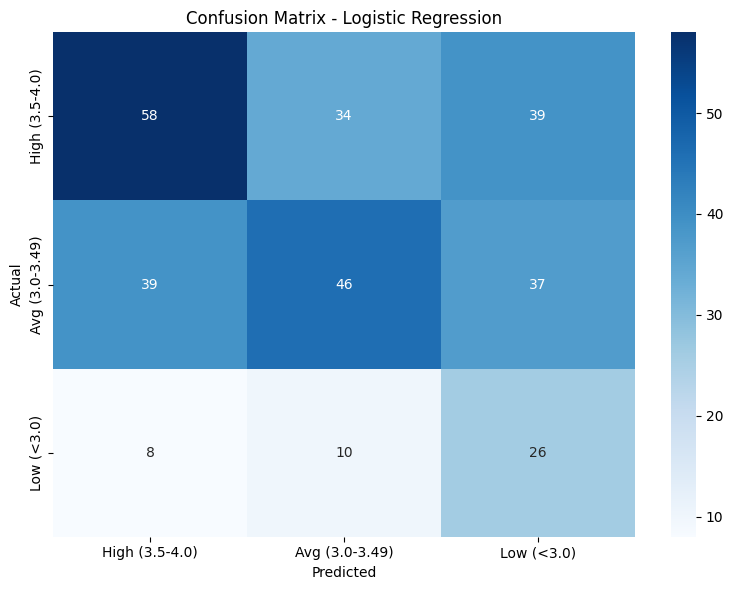


Classification Report - Logistic Regression
                precision    recall  f1-score   support

High (3.5-4.0)       0.55      0.44      0.49       131
Avg (3.0-3.49)       0.51      0.38      0.43       122
    Low (<3.0)       0.25      0.59      0.36        44

      accuracy                           0.44       297
     macro avg       0.44      0.47      0.43       297
  weighted avg       0.49      0.44      0.45       297



In [16]:
plot_confusion_matrix(y_test, y_pred_lr, 'Logistic Regression')
print_classification_report(y_test, y_pred_lr, 'Logistic Regression')

---
## 10. Model 6: Artificial Neural Network (PyTorch)

In [17]:
# Define Neural Network Architecture
class NeuralNetwork(nn.Module):
    def __init__(self, input_size, hidden_sizes, num_classes):
        super(NeuralNetwork, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(0.3))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, num_classes))
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

print("Neural Network class defined.")

Neural Network class defined.


In [18]:
# Prepare data for PyTorch
X_train_tensor = torch.FloatTensor(X_train).to(device)
y_train_tensor = torch.LongTensor(y_train).to(device)
X_test_tensor = torch.FloatTensor(X_test).to(device)
y_test_tensor = torch.LongTensor(y_test).to(device)

# Create DataLoader
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Initialize model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]
num_classes = 3

ann_model = NeuralNetwork(input_size, hidden_sizes, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(ann_model.parameters(), lr=0.001)

print(f"Model architecture:")
print(ann_model)

Model architecture:
NeuralNetwork(
  (network): Sequential(
    (0): Linear(in_features=29, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=32, bias=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=32, out_features=3, bias=True)
  )
)


In [19]:
# Training loop
print("Training Neural Network...")
epochs = 100
train_losses = []

for epoch in range(epochs):
    ann_model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = ann_model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_losses[-1]:.4f}")

print("\nTraining completed!")

Training Neural Network...
Epoch [20/100], Loss: 0.9233
Epoch [40/100], Loss: 0.8080
Epoch [60/100], Loss: 0.7060
Epoch [80/100], Loss: 0.6230
Epoch [100/100], Loss: 0.5751

Training completed!


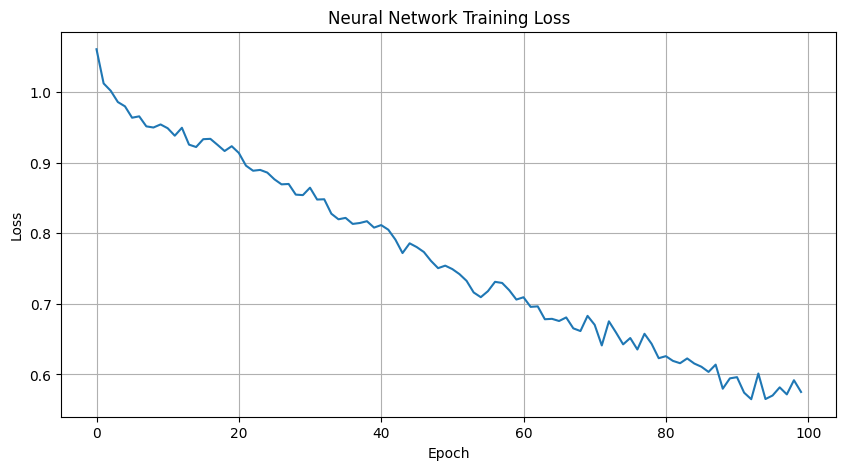

In [20]:
# Plot training loss
plt.figure(figsize=(10, 5))
plt.plot(train_losses)
plt.title('Neural Network Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

In [21]:
# Evaluate Neural Network
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    _, y_pred_ann = torch.max(outputs, 1)
    y_pred_ann = y_pred_ann.cpu().numpy()
    
    # Get probabilities for ROC-AUC
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred_ann)
macro_f1 = f1_score(y_test, y_pred_ann, average='macro')
balanced_acc = balanced_accuracy_score(y_test, y_pred_ann)
roc_auc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

result = {
    'Model': 'Neural Network',
    'Accuracy': round(accuracy, 4),
    'Macro F1-Score': round(macro_f1, 4),
    'Balanced Accuracy': round(balanced_acc, 4),
    'ROC-AUC': round(roc_auc, 4)
}
all_results.append(result)

print(f"\nNeural Network Results:")
for key, value in result.items():
    print(f"  {key}: {value}")


Neural Network Results:
  Model: Neural Network
  Accuracy: 0.468
  Macro F1-Score: 0.446
  Balanced Accuracy: 0.4369
  ROC-AUC: 0.6124


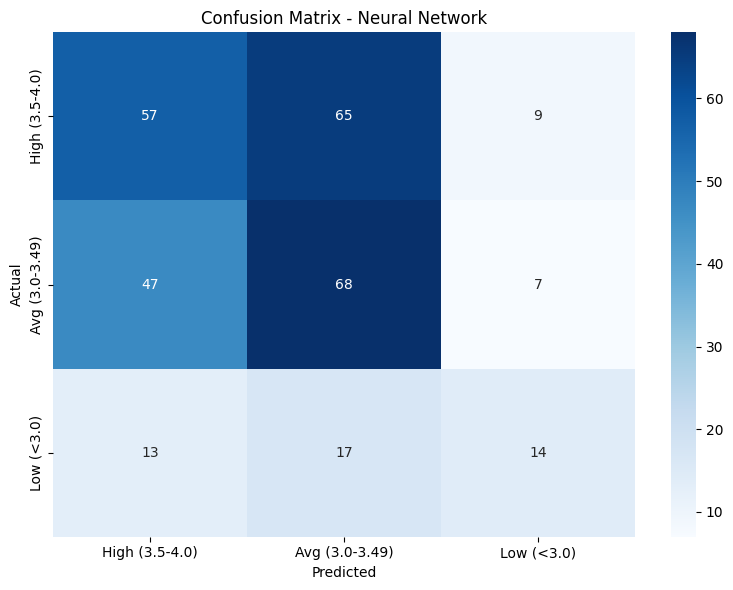


Classification Report - Neural Network
                precision    recall  f1-score   support

High (3.5-4.0)       0.49      0.44      0.46       131
Avg (3.0-3.49)       0.45      0.56      0.50       122
    Low (<3.0)       0.47      0.32      0.38        44

      accuracy                           0.47       297
     macro avg       0.47      0.44      0.45       297
  weighted avg       0.47      0.47      0.46       297



In [22]:
plot_confusion_matrix(y_test, y_pred_ann, 'Neural Network')
print_classification_report(y_test, y_pred_ann, 'Neural Network')

---
## 11. Model Comparison

In [23]:
# Create comparison dataframe
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

print("="*80)
print("MODEL COMPARISON - Balanced Normalized Data (GAN Augmented)")
print("="*80)
print(results_df.to_string(index=False))

MODEL COMPARISON - Balanced Normalized Data (GAN Augmented)
              Model  Accuracy  Macro F1-Score  Balanced Accuracy  ROC-AUC
            XGBoost    0.5219          0.5066             0.4951   0.6375
  Gradient Boosting    0.5051          0.4552             0.4464   0.6342
           CatBoost    0.4949          0.4766             0.4639   0.6203
      Random Forest    0.4747          0.4567             0.4434   0.6107
     Neural Network    0.4680          0.4460             0.4369   0.6124
Logistic Regression    0.4377          0.4272             0.4702   0.6229


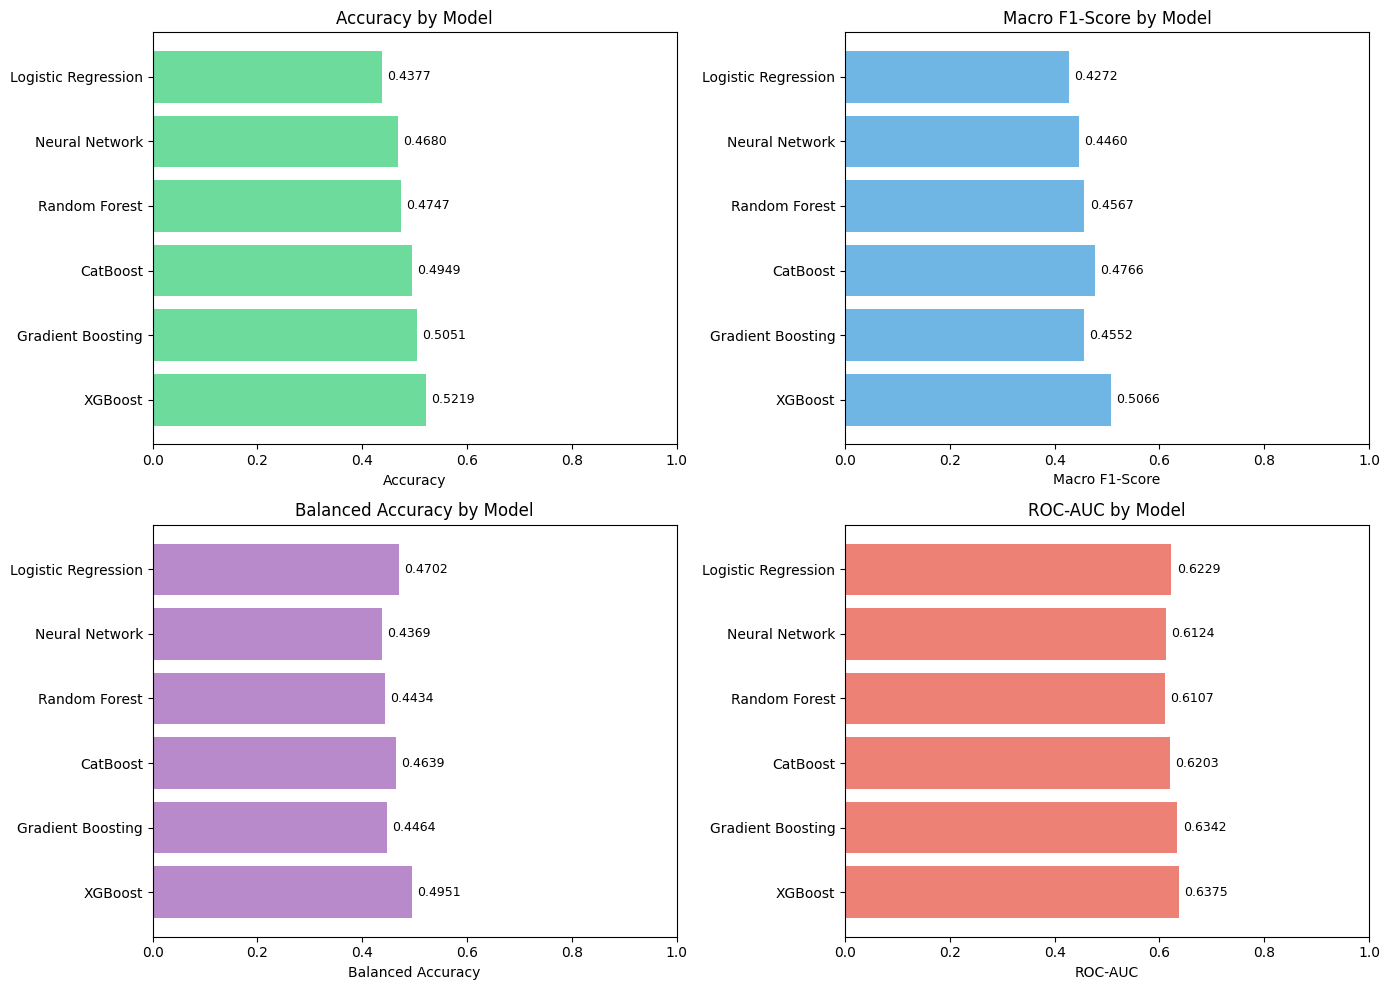


Figure saved to: ../images/model_comparison_balanced_normalized.png


In [24]:
# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['Accuracy', 'Macro F1-Score', 'Balanced Accuracy', 'ROC-AUC']
colors = ['#2ecc71', '#3498db', '#9b59b6', '#e74c3c']

for idx, (ax, metric, color) in enumerate(zip(axes.flat, metrics, colors)):
    if metric == 'ROC-AUC':
        # Handle 'N/A' values
        plot_df = results_df[results_df['ROC-AUC'] != 'N/A'].copy()
        plot_df['ROC-AUC'] = plot_df['ROC-AUC'].astype(float)
        values = plot_df[metric].values
        models = plot_df['Model'].values
    else:
        values = results_df[metric].values
        models = results_df['Model'].values
    
    bars = ax.barh(models, values, color=color, alpha=0.7)
    ax.set_xlabel(metric)
    ax.set_title(f'{metric} by Model')
    ax.set_xlim(0, 1)
    
    # Add value labels
    for bar, val in zip(bars, values):
        ax.text(val + 0.01, bar.get_y() + bar.get_height()/2, 
                f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../images/model_comparison_balanced_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/model_comparison_balanced_normalized.png")

In [25]:
# Save results to CSV
results_df.to_csv('../results/balanced_normalized_model_results.csv', index=False)
print("Results saved to: ../results/balanced_normalized_model_results.csv")
print("\n" + "="*80)
print("EXPERIMENT COMPLETE!")
print("="*80)

Results saved to: ../results/balanced_normalized_model_results.csv

EXPERIMENT COMPLETE!


## 12. Summary

This notebook ran 6 machine learning models on the GAN-augmented balanced normalized dataset:

1. **Random Forest** - Ensemble of decision trees
2. **Gradient Boosting** - Sequential boosting
3. **XGBoost** - Optimized gradient boosting
4. **CatBoost** - Gradient boosting with categorical support
5. **Logistic Regression** - Linear model for classification
6. **Neural Network** - Deep learning with PyTorch

### Key Points:
- Data is already normalized (values between 0 and 1)
- Classes are balanced using GAN-generated synthetic data
- No feature engineering applied - plain model runs
- Target: CGPA3_Class (3 classes)

---
## 13. Feature Importance Visualization

Visualizing which features contribute most to predictions for each model.

In [26]:
# Get feature importances from tree-based models
feature_importance_dict = {}

# Random Forest
feature_importance_dict['Random Forest'] = rf_model.feature_importances_

# Gradient Boosting
feature_importance_dict['Gradient Boosting'] = gb_model.feature_importances_

# XGBoost
feature_importance_dict['XGBoost'] = xgb_model.feature_importances_

# CatBoost
feature_importance_dict['CatBoost'] = catboost_model.feature_importances_

# Logistic Regression (use absolute coefficients averaged across classes)
lr_importance = np.mean(np.abs(lr_model.coef_), axis=0)
lr_importance = lr_importance / lr_importance.sum()  # Normalize
feature_importance_dict['Logistic Regression'] = lr_importance

print("Feature importances extracted for all models!")

Feature importances extracted for all models!


In [27]:
# Create feature importance dataframe
importance_df = pd.DataFrame(feature_importance_dict, index=feature_cols)
importance_df['Average'] = importance_df.mean(axis=1)
importance_df = importance_df.sort_values('Average', ascending=False)

print("Top 15 Most Important Features (Averaged across models):")
print("="*60)
print(importance_df['Average'].head(15).to_string())
print("\nBottom 5 Least Important Features:")
print(importance_df['Average'].tail(5).to_string())

Top 15 Most Important Features (Averaged across models):
Focus_on_Academic_Task                2.037311
Sleepiness_During_Class               1.812675
Impact_of_Sleep_on_Academic           1.743974
Rate_Sleep_Quality                    1.463510
Where_live                            1.304167
Struggle_to_Sleep                     1.283668
Main_Reason_for_Insufficient_Sleep    1.133291
Daily_Academics_Time_Spend            1.126152
Class_Attendance                      1.096458
AVG_Sleep_Per_Night                   0.840101
Age                                   0.808086
Sleep_Condition                       0.792200
Daytime_Nap                           0.514493
Exam_Night_Bed_Time                   0.511077
Consume_Caffeine_Night                0.465920

Bottom 5 Least Important Features:
Holiday_WakeUp_Time              0.243904
Dinnar_Time                      0.207443
Holiday_Bed_Time                 0.185827
Sleep_Affecting_Drugs            0.149985
Electronic_Devices_Before_Bed    0

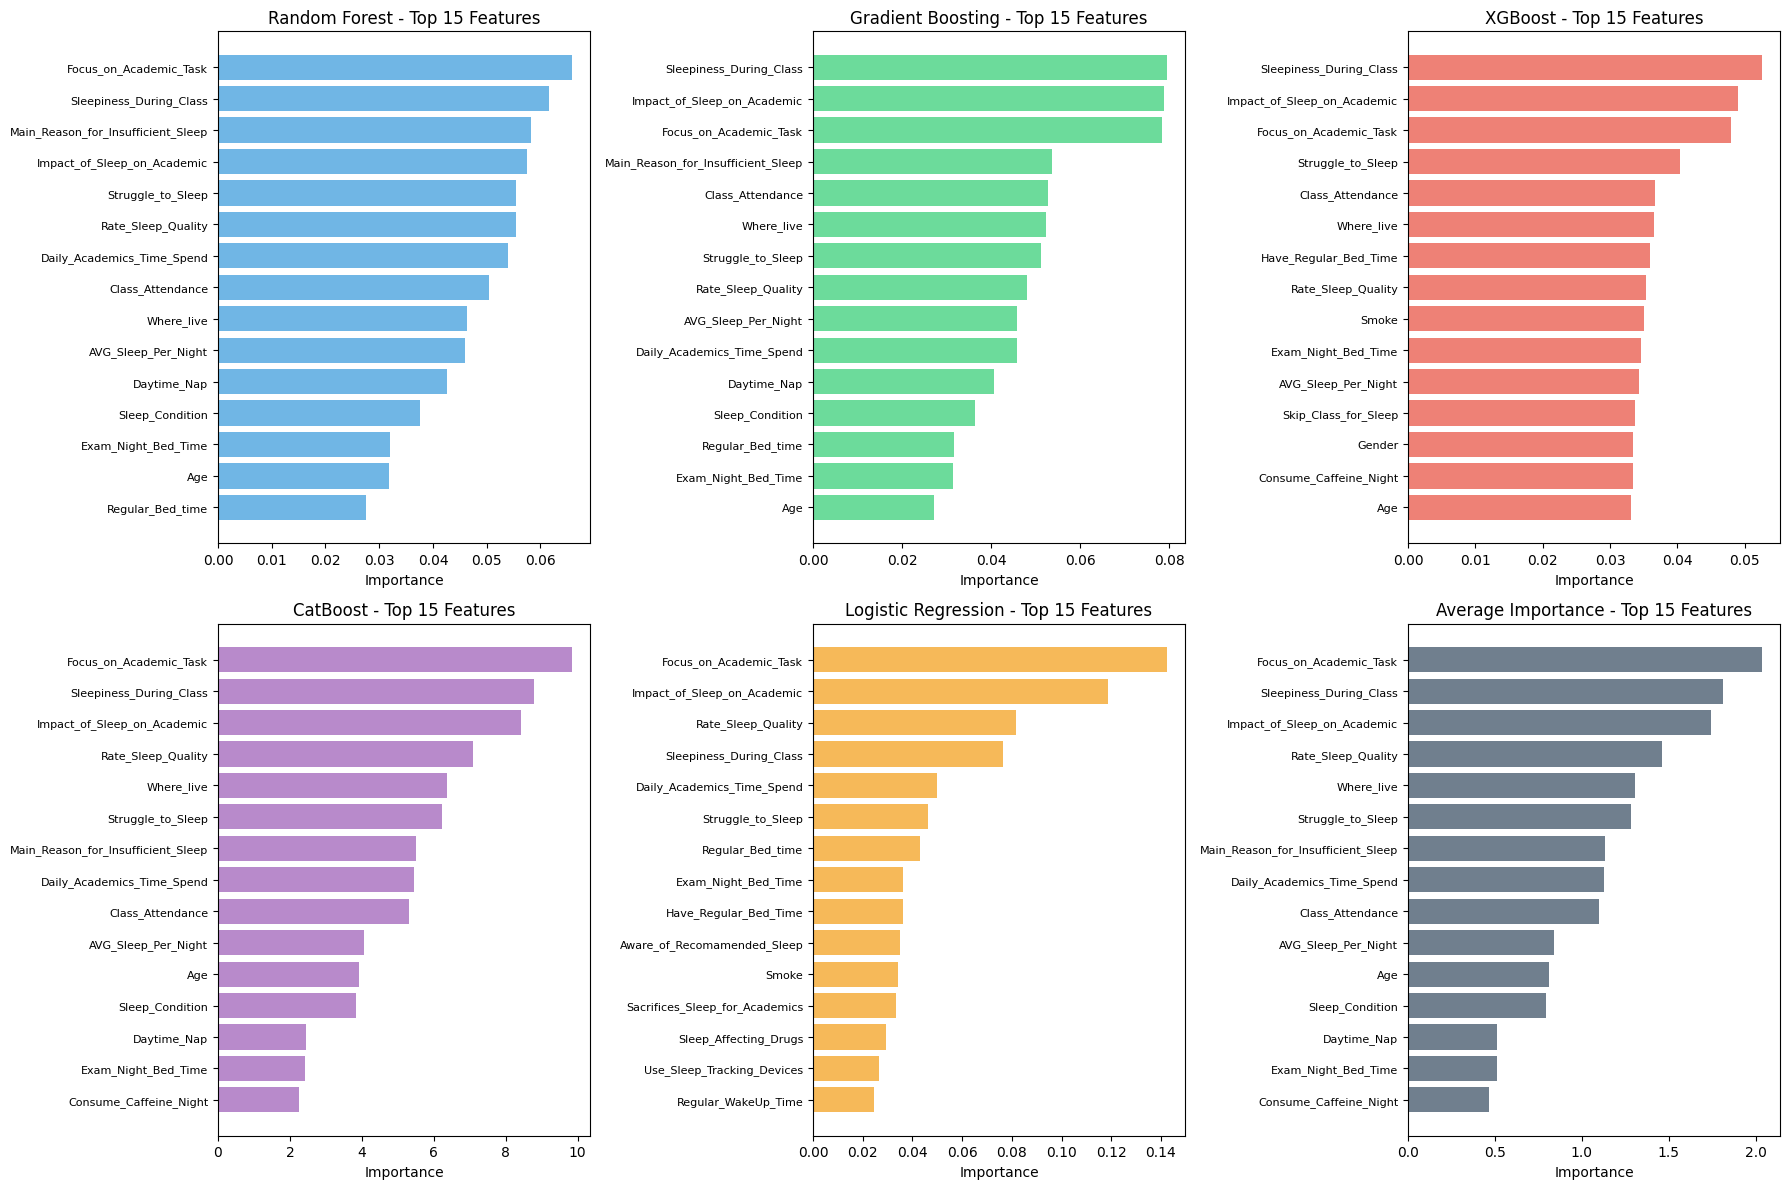


Figure saved to: ../images/feature_importance_all_models.png


In [28]:
# Visualize feature importance for each model
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
models_to_plot = ['Random Forest', 'Gradient Boosting', 'XGBoost', 'CatBoost', 'Logistic Regression']
colors = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12']

for idx, (ax, model_name, color) in enumerate(zip(axes.flat[:5], models_to_plot, colors)):
    # Get top 15 features for this model
    model_importance = importance_df[model_name].sort_values(ascending=True).tail(15)
    
    ax.barh(model_importance.index, model_importance.values, color=color, alpha=0.7)
    ax.set_xlabel('Importance')
    ax.set_title(f'{model_name} - Top 15 Features')
    ax.tick_params(axis='y', labelsize=8)

# Average importance in the last subplot
ax = axes.flat[5]
avg_importance = importance_df['Average'].sort_values(ascending=True).tail(15)
ax.barh(avg_importance.index, avg_importance.values, color='#34495e', alpha=0.7)
ax.set_xlabel('Importance')
ax.set_title('Average Importance - Top 15 Features')
ax.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('../images/feature_importance_all_models.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_all_models.png")

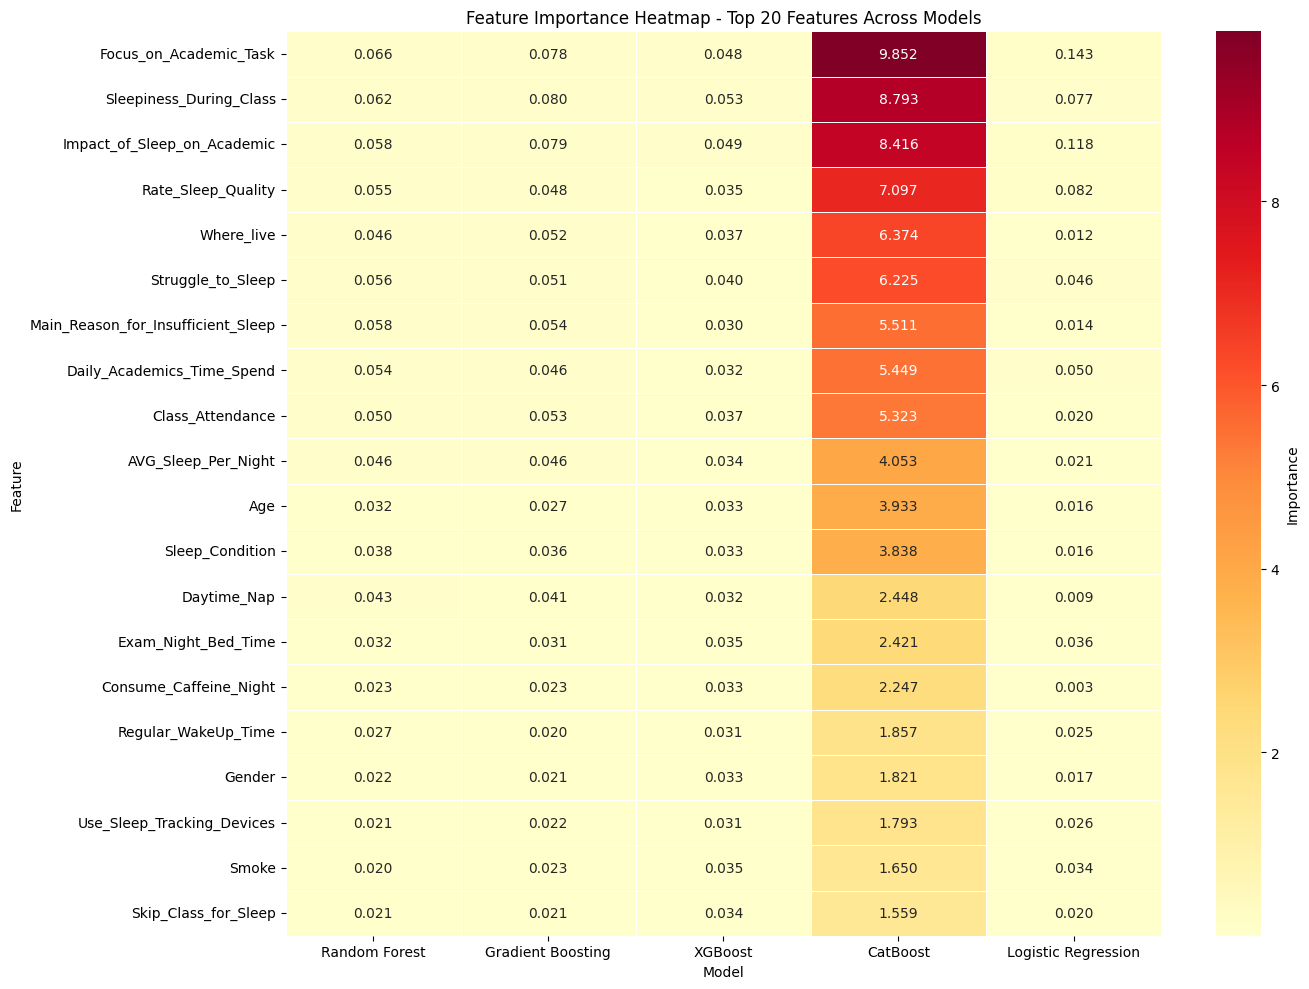


Figure saved to: ../images/feature_importance_heatmap.png


In [29]:
# Heatmap of feature importance across all models
plt.figure(figsize=(14, 10))

# Get top 20 features by average importance
top_features = importance_df['Average'].sort_values(ascending=False).head(20).index
heatmap_data = importance_df.loc[top_features, models_to_plot]

sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd', 
            linewidths=0.5, cbar_kws={'label': 'Importance'})
plt.title('Feature Importance Heatmap - Top 20 Features Across Models')
plt.xlabel('Model')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('../images/feature_importance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved to: ../images/feature_importance_heatmap.png")

In [30]:
# Save feature importance to CSV
importance_df.to_csv('../results/feature_importance_all_models.csv')
print("Feature importance saved to: ../results/feature_importance_all_models.csv")

# Summary of most important features
print("\n" + "="*60)
print("FEATURE IMPORTANCE SUMMARY")
print("="*60)
print("\nTop 10 Most Influential Features (by average importance):")
for i, (feature, importance) in enumerate(importance_df['Average'].head(10).items(), 1):
    print(f"  {i}. {feature}: {importance:.4f}")

Feature importance saved to: ../results/feature_importance_all_models.csv

FEATURE IMPORTANCE SUMMARY

Top 10 Most Influential Features (by average importance):
  1. Focus_on_Academic_Task: 2.0373
  2. Sleepiness_During_Class: 1.8127
  3. Impact_of_Sleep_on_Academic: 1.7440
  4. Rate_Sleep_Quality: 1.4635
  5. Where_live: 1.3042
  6. Struggle_to_Sleep: 1.2837
  7. Main_Reason_for_Insufficient_Sleep: 1.1333
  8. Daily_Academics_Time_Spend: 1.1262
  9. Class_Attendance: 1.0965
  10. AVG_Sleep_Per_Night: 0.8401


## 14. 📊 Model Performance Summary Table

Comprehensive comparison of all models with key metrics including precision, recall, F1-score, cross-validation accuracy, and overfitting analysis.

In [31]:
# ============================================================================
# SIMPLE COMPREHENSIVE MODEL COMPARISON TABLE
# ============================================================================

from sklearn.metrics import precision_score, recall_score, roc_auc_score

print("Creating comprehensive model comparison table...\n")

# Store results for all models
all_model_results = []

# ===== 1. GRADIENT BOOSTING =====
gb_acc = accuracy_score(y_test, y_pred_gb)
gb_prec = precision_score(y_test, y_pred_gb, average='macro')
gb_rec = recall_score(y_test, y_pred_gb, average='macro')
gb_f1 = f1_score(y_test, y_pred_gb, average='macro')
gb_roc = roc_auc_score(y_test, gb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Gradient Boosting',
    'Accuracy': round(gb_acc, 4),
    'Precision': round(gb_prec, 4),
    'Recall': round(gb_rec, 4),
    'F1-Score': round(gb_f1, 4),
    'ROC-AUC': round(gb_roc, 4)
})

# ===== 2. XGBOOST =====
xgb_acc = accuracy_score(y_test, y_pred_xgb)
xgb_prec = precision_score(y_test, y_pred_xgb, average='macro')
xgb_rec = recall_score(y_test, y_pred_xgb, average='macro')
xgb_f1 = f1_score(y_test, y_pred_xgb, average='macro')
xgb_roc = roc_auc_score(y_test, xgb_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'XGBoost',
    'Accuracy': round(xgb_acc, 4),
    'Precision': round(xgb_prec, 4),
    'Recall': round(xgb_rec, 4),
    'F1-Score': round(xgb_f1, 4),
    'ROC-AUC': round(xgb_roc, 4)
})

# ===== 3. CATBOOST =====
cb_acc = accuracy_score(y_test, y_pred_cat)
cb_prec = precision_score(y_test, y_pred_cat, average='macro')
cb_rec = recall_score(y_test, y_pred_cat, average='macro')
cb_f1 = f1_score(y_test, y_pred_cat, average='macro')
cb_roc = roc_auc_score(y_test, catboost_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'CatBoost',
    'Accuracy': round(cb_acc, 4),
    'Precision': round(cb_prec, 4),
    'Recall': round(cb_rec, 4),
    'F1-Score': round(cb_f1, 4),
    'ROC-AUC': round(cb_roc, 4)
})

# ===== 4. RANDOM FOREST =====
rf_acc = accuracy_score(y_test, y_pred_rf)
rf_prec = precision_score(y_test, y_pred_rf, average='macro')
rf_rec = recall_score(y_test, y_pred_rf, average='macro')
rf_f1 = f1_score(y_test, y_pred_rf, average='macro')
rf_roc = roc_auc_score(y_test, rf_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Random Forest',
    'Accuracy': round(rf_acc, 4),
    'Precision': round(rf_prec, 4),
    'Recall': round(rf_rec, 4),
    'F1-Score': round(rf_f1, 4),
    'ROC-AUC': round(rf_roc, 4)
})

# ===== 5. LOGISTIC REGRESSION =====
lr_acc = accuracy_score(y_test, y_pred_lr)
lr_prec = precision_score(y_test, y_pred_lr, average='macro')
lr_rec = recall_score(y_test, y_pred_lr, average='macro')
lr_f1 = f1_score(y_test, y_pred_lr, average='macro')
lr_roc = roc_auc_score(y_test, lr_model.predict_proba(X_test), multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Logistic Regression',
    'Accuracy': round(lr_acc, 4),
    'Precision': round(lr_prec, 4),
    'Recall': round(lr_rec, 4),
    'F1-Score': round(lr_f1, 4),
    'ROC-AUC': round(lr_roc, 4)
})

# ===== 6. NEURAL NETWORK =====
ann_model.eval()
with torch.no_grad():
    outputs = ann_model(X_test_tensor)
    y_prob_ann = torch.softmax(outputs, dim=1).cpu().numpy()

ann_acc = accuracy_score(y_test, y_pred_ann)
ann_prec = precision_score(y_test, y_pred_ann, average='macro')
ann_rec = recall_score(y_test, y_pred_ann, average='macro')
ann_f1 = f1_score(y_test, y_pred_ann, average='macro')
ann_roc = roc_auc_score(y_test, y_prob_ann, multi_class='ovr', average='macro')

all_model_results.append({
    'Model': 'Neural Network',
    'Accuracy': round(ann_acc, 4),
    'Precision': round(ann_prec, 4),
    'Recall': round(ann_rec, 4),
    'F1-Score': round(ann_f1, 4),
    'ROC-AUC': round(ann_roc, 4)
})

# Create DataFrame and sort by accuracy
final_comparison_df = pd.DataFrame(all_model_results)
final_comparison_df = final_comparison_df.sort_values('Accuracy', ascending=False).reset_index(drop=True)

# Add rank
final_comparison_df.insert(0, 'Rank', range(1, len(final_comparison_df) + 1))

# Display table
print("=" * 95)
print("COMPREHENSIVE MODEL PERFORMANCE COMPARISON")
print("=" * 95)
print(final_comparison_df.to_string(index=False))
print("=" * 95)

# Summary
best_model = final_comparison_df.iloc[0]['Model']
best_acc = final_comparison_df.iloc[0]['Accuracy']

print(f"\n🏆 Best Model: {best_model}")
print(f"📊 Best Accuracy: {best_acc:.4f} ({best_acc*100:.2f}%)")
print(f"📈 Models Compared: {len(final_comparison_df)}")
print("=" * 95)

# Save results
final_comparison_df.to_csv('../results/final_model_comparison.csv', index=False)
print("\n✓ Results saved to: ../results/final_model_comparison.csv")

Creating comprehensive model comparison table...

COMPREHENSIVE MODEL PERFORMANCE COMPARISON
 Rank               Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
    1             XGBoost    0.5219     0.5293  0.4951    0.5066   0.6375
    2   Gradient Boosting    0.5051     0.5036  0.4464    0.4552   0.6342
    3            CatBoost    0.4949     0.5066  0.4639    0.4766   0.6203
    4       Random Forest    0.4747     0.4882  0.4434    0.4567   0.6107
    5      Neural Network    0.4680     0.4691  0.4369    0.4460   0.6124
    6 Logistic Regression    0.4377     0.4395  0.4702    0.4272   0.6229

🏆 Best Model: XGBoost
📊 Best Accuracy: 0.5219 (52.19%)
📈 Models Compared: 6

✓ Results saved to: ../results/final_model_comparison.csv
